In [311]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
import statsmodels.stats.outliers_influence as oi
import statsmodels.stats.api as sms
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [312]:
df = pd.read_csv('../data/df_final_with_dummies.csv', sep=';') 
print(df.head())

                Регионы   X1    X2     X3     X4  X5_thous    X6    ln_Y  D1
0  Белгородская область  4.9  65.4  17.40  57.19    -3.649  0.60 -0.4404   0
1      Брянская область  4.0  69.5  16.02  33.66    -1.588  0.57 -1.0505   0
2  Владимирская область  5.6  77.7  15.83  33.43    -3.588  0.59 -0.9044   0
3   Воронежская область  4.3  68.3  19.87  46.21     4.392  0.55 -0.7840   0
4    Ивановская область  5.4  81.8  16.16  15.34    -0.772  0.62 -1.2559   0


In [313]:
# Отбираем факторы для кластеризации
features = ['X1', 'X2', 'X3']
X = df[features]

# Обучаем модель на 3 кластера 
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Создаем три отдельные выборки
sub_sample_1 = df[df['Cluster'] == 0]
sub_sample_2 = df[df['Cluster'] == 1]
sub_sample_3 = df[df['Cluster'] == 2]

print("Распределение регионов по кластерам:")
print(df['Cluster'].value_counts())

Распределение регионов по кластерам:
Cluster
1    35
2    32
0    10
Name: count, dtype: int64


In [314]:
df_c1 = df[df['Cluster'] == 0].copy()

factors = ['X1', 'X2', 'X3', 'X4', 'X5_thous', 'X6']
target = df_c1['ln_Y']
while len(factors) > 0:
    X = sm.add_constant(df_c1[factors])
    model = sm.OLS(target, X).fit()
    p_values = model.pvalues.drop('const')
    max_p = p_values.max()
    
    if max_p > 0.05:
        excluded_feature = p_values.idxmax()
        print(f"Исключаем фактор '{excluded_feature}' с p-value = {max_p:.4f}")
        factors.remove(excluded_feature)
    else:
        break
print(model.summary())

Исключаем фактор 'X2' с p-value = 0.6004
Исключаем фактор 'X4' с p-value = 0.6142
Исключаем фактор 'X5_thous' с p-value = 0.5803
Исключаем фактор 'X3' с p-value = 0.2166
Исключаем фактор 'X6' с p-value = 0.1317
                            OLS Regression Results                            
Dep. Variable:                   ln_Y   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares   F-statistic:                     15.64
Date:                Fri, 01 May 2026   Prob (F-statistic):            0.00421
Time:                        14:36:14   Log-Likelihood:                 4.6060
No. Observations:                  10   AIC:                            -5.212
Df Residuals:                       8   BIC:                            -4.607
Df Model:                           1                                         
Covariance Type:            nonrobust                                         

In [315]:
ss_reg = model.ess             # Сумма квадратов
ss_res = model.ssr             # Сумма квадартов остатков
ss_total = ss_reg + ss_res     # Общая сумма

df_reg = model.df_model        # Степени свободы регрессии
df_res = model.df_resid        # Степени свободы остатков (n-k-1)

ms_reg = ss_reg / df_reg # Средние суммы квадратов регрессии
ms_res = ss_res / df_res #Средние суммы квадратов остатков

f_stat = model.fvalue
p_val = model.f_pvalue

print(f"{'Источник':<15} | {'SS':<10} | {'df':<5} | {'MS':<10}")
print("-" * 50)
print(f"{'Регрессия':<15} | {ss_reg:<10.4f} | {int(df_reg):<5} | {ms_reg:<10.4f}")
print(f"{'Остатки':<15} | {ss_res:<10.4f} | {int(df_res):<5} | {ms_res:<10.4f}")
print(f"{'Итого':<15} | {ss_total:<10.4f} | {int(df_reg + df_res):<5}")
print("-" * 50)
print(f"F-статистика: {f_stat:.4f}, p-value: {p_val:.10f}")

Источник        | SS         | df    | MS        
--------------------------------------------------
Регрессия       | 0.4556     | 1     | 0.4556    
Остатки         | 0.2331     | 8     | 0.0291    
Итого           | 0.6886     | 9    
--------------------------------------------------
F-статистика: 15.6379, p-value: 0.0042094933


Так как p < 0,05 следовательно модель значима.

In [316]:
df_c1 = df[df['Cluster'] == 1].copy()

factors = ['X1', 'X2', 'X3', 'X4', 'X5_thous', 'X6']
target = df_c1['ln_Y']
while len(factors) > 0:
    X = sm.add_constant(df_c1[factors])
    model = sm.OLS(target, X).fit()
    p_values = model.pvalues.drop('const')
    max_p = p_values.max()
    
    if max_p > 0.05:
        excluded_feature = p_values.idxmax()
        print(f"Исключаем фактор '{excluded_feature}' с p-value = {max_p:.4f}")
        factors.remove(excluded_feature)
    else:
        break
print(model.summary())

Исключаем фактор 'X3' с p-value = 0.8304
Исключаем фактор 'X2' с p-value = 0.6916
Исключаем фактор 'X6' с p-value = 0.2943
Исключаем фактор 'X5_thous' с p-value = 0.1597
Исключаем фактор 'X1' с p-value = 0.2825
Исключаем фактор 'X4' с p-value = 0.2325
                            OLS Regression Results                            
Dep. Variable:                   ln_Y   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     1.479
Date:                Fri, 01 May 2026   Prob (F-statistic):              0.233
Time:                        14:36:14   Log-Likelihood:                -10.353
No. Observations:                  35   AIC:                             24.71
Df Residuals:                      33   BIC:                             27.82
Df Model:                           1                                         
Covariance Type:            nonrobust

In [317]:
ss_reg = model.ess             # Сумма квадратов
ss_res = model.ssr             # Сумма квадартов остатков
ss_total = ss_reg + ss_res     # Общая сумма

df_reg = model.df_model        # Степени свободы регрессии
df_res = model.df_resid        # Степени свободы остатков (n-k-1)

ms_reg = ss_reg / df_reg # Средние суммы квадратов регрессии
ms_res = ss_res / df_res #Средние суммы квадратов остатков

f_stat = model.fvalue
p_val = model.f_pvalue

print(f"{'Источник':<15} | {'SS':<10} | {'df':<5} | {'MS':<10}")
print("-" * 50)
print(f"{'Регрессия':<15} | {ss_reg:<10.4f} | {int(df_reg):<5} | {ms_reg:<10.4f}")
print(f"{'Остатки':<15} | {ss_res:<10.4f} | {int(df_res):<5} | {ms_res:<10.4f}")
print(f"{'Итого':<15} | {ss_total:<10.4f} | {int(df_reg + df_res):<5}")
print("-" * 50)
print(f"F-статистика: {f_stat:.4f}, p-value: {p_val:.10f}")

Источник        | SS         | df    | MS        
--------------------------------------------------
Регрессия       | 0.1660     | 1     | 0.1660    
Остатки         | 3.7027     | 33    | 0.1122    
Итого           | 3.8686     | 34   
--------------------------------------------------
F-статистика: 1.4791, p-value: 0.2325418054


Так как p > 0,05 следовательно модель незначима. 

In [318]:
df_c1 = df[df['Cluster'] == 2].copy()

factors = ['X1', 'X2', 'X3', 'X4', 'X5_thous', 'X6']
target = df_c1['ln_Y']
while len(factors) > 0:
    X = sm.add_constant(df_c1[factors])
    model = sm.OLS(target, X).fit()
    p_values = model.pvalues.drop('const')
    max_p = p_values.max()
    
    if max_p > 0.05:
        excluded_feature = p_values.idxmax()
        print(f"Исключаем фактор '{excluded_feature}' с p-value = {max_p:.4f}")
        factors.remove(excluded_feature)
    else:
        break
print(model.summary())

Исключаем фактор 'X6' с p-value = 0.9646
Исключаем фактор 'X3' с p-value = 0.7020
Исключаем фактор 'X5_thous' с p-value = 0.2887
Исключаем фактор 'X4' с p-value = 0.2857
Исключаем фактор 'X2' с p-value = 0.2264
Исключаем фактор 'X1' с p-value = 0.1199
                            OLS Regression Results                            
Dep. Variable:                   ln_Y   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     2.562
Date:                Fri, 01 May 2026   Prob (F-statistic):              0.120
Time:                        14:36:14   Log-Likelihood:                -7.1939
No. Observations:                  32   AIC:                             18.39
Df Residuals:                      30   BIC:                             21.32
Df Model:                           1                                         
Covariance Type:            nonrobust

In [319]:
ss_reg = model.ess             # Сумма квадратов
ss_res = model.ssr             # Сумма квадартов остатков
ss_total = ss_reg + ss_res     # Общая сумма

df_reg = model.df_model        # Степени свободы регрессии
df_res = model.df_resid        # Степени свободы остатков (n-k-1)

ms_reg = ss_reg / df_reg # Средние суммы квадратов регрессии
ms_res = ss_res / df_res #Средние суммы квадратов остатков

f_stat = model.fvalue
p_val = model.f_pvalue

print(f"{'Источник':<15} | {'SS':<10} | {'df':<5} | {'MS':<10}")
print("-" * 50)
print(f"{'Регрессия':<15} | {ss_reg:<10.4f} | {int(df_reg):<5} | {ms_reg:<10.4f}")
print(f"{'Остатки':<15} | {ss_res:<10.4f} | {int(df_res):<5} | {ms_res:<10.4f}")
print(f"{'Итого':<15} | {ss_total:<10.4f} | {int(df_reg + df_res):<5}")
print("-" * 50)
print(f"F-статистика: {f_stat:.4f}, p-value: {p_val:.10f}")

Источник        | SS         | df    | MS        
--------------------------------------------------
Регрессия       | 0.2508     | 1     | 0.2508    
Остатки         | 2.9373     | 30    | 0.0979    
Итого           | 3.1881     | 31   
--------------------------------------------------
F-статистика: 2.5620, p-value: 0.1199401038


Так как p > 0,05 следовательно модель незначима. 

In [320]:
n = [0, 8, 30, 39]           # Размеры выборок
ss = [0, 0.1746, 3.5135, 2.9684] # Суммы квадратов остатков (SS)
k = 2 # Количество параметров в модели

# Список пар для сравнения: (Первый кластер, Второй кластер, Общее SS пары)
comparisons = [
    (1, 2, 3.7705),
    (1, 3, 3.2890),
    (2, 3, 6.6696)
]

print("Результаты теста Чоу:")
print("-" * 40)

for c1, c2, ss_combined in comparisons:
    # Считаем сумму остатков внутри двух кластеров
    ss_sum_inside = ss[c1] + ss[c2]
    
    # Считаем степени свободы
    df1 = k
    df2 = n[c1] + n[c2] - 2 * k
    
    # Считаем F-статистику по частям (числитель и знаменатель)
    top = (ss_combined - ss_sum_inside) / df1
    bottom = ss_sum_inside / df2
    f_calc = top / bottom
    
    # Считаем критическое значение (уровень значимости 0.05)
    f_crit = stats.f.ppf(0.95, df1, df2)

    print(f"Кластеры {c1} и {c2}: F-расч = {f_calc:.4f} | F-крит = {f_crit:.4f}")

Результаты теста Чоу:
----------------------------------------
Кластеры 1 и 2: F-расч = 0.3798 | F-крит = 3.2759
Кластеры 1 и 3: F-расч = 0.9987 | F-крит = 3.2145
Кластеры 2 и 3: F-расч = 0.9411 | F-крит = 3.1381


По результатам попарного теста Чоу для всех комбинаций кластеров было получено соотношение Fрасч<Fкрит, что позволяет принять гипотезу о стабильности параметров модели. Это статистически обосновывает использование единого уравнения регрессии для всей совокупности регионов с введением дамми-переменных для учета кластерных сдвигов

In [321]:
# Создаем две колонки дамми-переменных для кластеров
df['cl1'] = (df['Cluster'] == 0).astype(int) 
df['cl2'] = (df['Cluster'] == 1).astype(int)

factors = ['X1', 'X2', 'X3', 'X4', 'X5_thous', 'X6', 'D1', 'cl1', 'cl2']
target = df['ln_Y']

while len(factors) > 0:
    X = sm.add_constant(df[factors])
    model = sm.OLS(target, X).fit()
    
    p_values = model.pvalues.drop('const')
    max_p = p_values.max()
    
    if max_p > 0.05:
        excluded_feature = p_values.idxmax()
        print(f"Исключаем фактор '{excluded_feature}' с p-value = {max_p:.4f}")
        factors.remove(excluded_feature)
    else:
        break

print(model.summary())

Исключаем фактор 'X2' с p-value = 0.7650
Исключаем фактор 'X4' с p-value = 0.6957
Исключаем фактор 'X3' с p-value = 0.2578
Исключаем фактор 'X5_thous' с p-value = 0.1548
                            OLS Regression Results                            
Dep. Variable:                   ln_Y   R-squared:                       0.584
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     19.93
Date:                Fri, 01 May 2026   Prob (F-statistic):           2.32e-12
Time:                        14:36:14   Log-Likelihood:                -5.9075
No. Observations:                  77   AIC:                             23.82
Df Residuals:                      71   BIC:                             37.88
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err        

Получена модель ln(y) = -1,46 - 0,028 * X1 + 1,245 * X2 + 0,482γ - 0,356cl1 + 0,147cl2 + ε,\
где γ – фиктивная переменная,\
cl1 – принадлежность к кластеру 1,\
cl2 – принадлежность к кластеру 2.\
Регион будет принадлежать к кластеру 3, если cl1 и cl2 одновременно будут равны 0. 

Проведем дисперсионный анализ, для оценки адекватности модели

In [322]:
ss_reg = model.ess             # Сумма квадратов
ss_res = model.ssr             # Сумма квадартов остатков
ss_total = ss_reg + ss_res     # Общая сумма

df_reg = model.df_model        # Степени свободы регрессии
df_res = model.df_resid        # Степени свободы остатков (n-k-1)

ms_reg = ss_reg / df_reg # Средние суммы квадратов регрессии
ms_res = ss_res / df_res #Средние суммы квадратов остатков

f_stat = model.fvalue
p_val = model.f_pvalue

print(f"{'Источник':<15} | {'SS':<10} | {'df':<5} | {'MS':<10}")
print("-" * 50)
print(f"{'Регрессия':<15} | {ss_reg:<10.4f} | {int(df_reg):<5} | {ms_reg:<10.4f}")
print(f"{'Остатки':<15} | {ss_res:<10.4f} | {int(df_res):<5} | {ms_res:<10.4f}")
print(f"{'Итого':<15} | {ss_total:<10.4f} | {int(df_reg + df_res):<5}")
print("-" * 50)
print(f"F-статистика: {f_stat:.4f}, p-value: {p_val:.10f}")

Источник        | SS         | df    | MS        
--------------------------------------------------
Регрессия       | 7.3768     | 5     | 1.4754    
Остатки         | 5.2560     | 71    | 0.0740    
Итого           | 12.6328    | 76   
--------------------------------------------------
F-статистика: 19.9298, p-value: 0.0000000000


Так как p < 0,05 следовательно модель значима. Проведем основные статистические тесты

{'Test Statistic': np.float64(18.618974199030877), 'Test Statistic p-value': np.float64(0.23152212184160942), 'F-Statistic': np.float64(1.2969481214814262), 'F-Test p-value': np.float64(0.2321632780377819)}


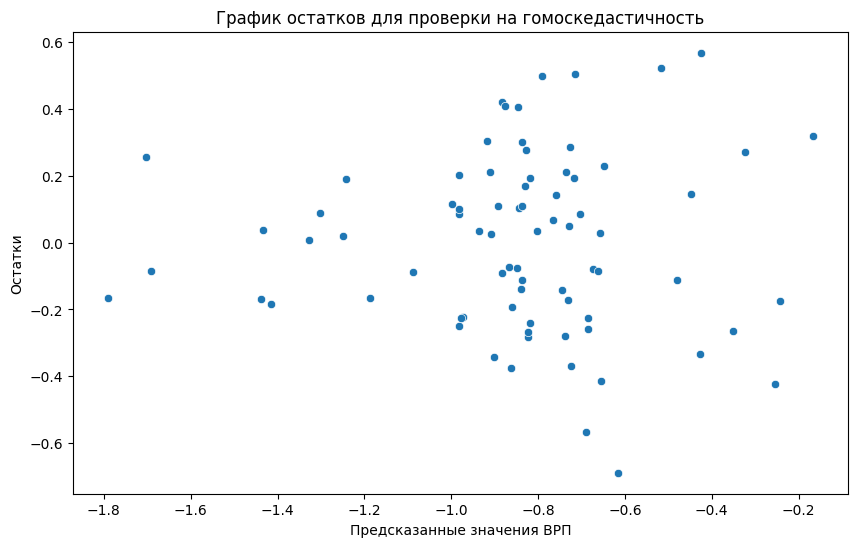

In [323]:
labels = ['Test Statistic', 'Test Statistic p-value', 'F-Statistic', 'F-Test p-value']
white_test = het_white(model.resid, model.model.exog)
print(dict(zip(labels, white_test)))

fitted_vals = model.fittedvalues # предсказания у
residuals = model.resid # остатки

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.xlabel('Предсказанные значения ВРП')
plt.ylabel('Остатки')
plt.title('График остатков для проверки на гомоскедастичность')
plt.show()

Так как полученное p-значение p = 0,23 превышает уровень значимости 0.05, у нас нет оснований отвергнуть нулевую гипотезу. Следовательно, гетероскедастичность в модели не обнаружена, и остатки можно считать гомоскедастичными.

Проверим модель с помощью RESET-теста

In [324]:
reset_test = oi.reset_ramsey(model, degree=3)
print("ТЕСТ РАМСЕЯ:")
print(f"F-статистика: {float(reset_test.fvalue):.4f}")
print(f"p-value: {float(reset_test.pvalue):.4f}")

ТЕСТ РАМСЕЯ:
F-статистика: 0.1908
p-value: 0.8267


Результаты теста Рамсея (RESET) показывают, что p-значение равно 0,8267, что значительно выше любого общепринятого уровня значимости (0,05). Следовательно, у нас нет оснований отвергать нулевую гипотезу. Это означает, что спецификация модели является адекватной и в ней отсутствуют существенные пропущенные переменные или неправильный функциональный вид.

А также проверим остатки на нормальное распределениe по тесту Харке - Бера.

In [325]:
name = ['Jarque-Bera', 'Chi^2 p-value']
test = sms.jarque_bera(model.resid)
print(dict(zip(name, test)))

{'Jarque-Bera': np.float64(0.34663086277128), 'Chi^2 p-value': np.float64(0.8408723354821768)}


Так как полученное p-значение p = 0,84 что превышает уровень значимости 0.05, значит у нас нет оснований отвергнуть гипотезу H_0. Следовательно остатки распределены нормально.

Следовательно итоговая модель выглядит так:\
ln(y) = -1,46 - 0,028 * X1 + 1,245 * X2 + 0,482γ - 0,356cl1 + 0,147cl2 + ε,\
где γ – фиктивная переменная,\
cl1 – принадлежность к кластеру 1,\
cl2 – принадлежность к кластеру 2.\
Регион будет принадлежать к кластеру 3, если cl1 и cl2 одновременно будут равны 0.\
\
Коэффициент детерминации: 0,58\
F-статистика: 29,93 > 3,1\
Критерий Акаике (AIC): 22,82\
Тест Уайта: 0.23 > 0,05\
Тест Харке - Бера: 0,84 > 0,05